# ARIMA Forecasting Procedure

| Step | Action | Data Used |
|------|--------|-----------|
| 1 | Split dataset to train/test | Full data |
| 2 | Choose p,d,q (auto_arima or grid search) | Train only |
| 3 | Cross-validate to verify choice | Train only |
| 4 | Fit model with chosen params | Train only |
| 5 | Evaluate on test (unbiased check) | Test |
| 6 | Re-fit on full dataset | Train + Test |
| 7 | Forecast future | Model from step 6 |

```
[=====Train=====][==Test==][???Future???]
        ↓             ↓          ↓
   Fit model     Evaluate    Forecast
   (steps 2-4)   (step 5)    (steps 6-7)
```

In [ ]:
# This is a forecast notebook for GPU usage for the year 2025
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.api as sm

In [24]:
# Exploratory analisys of the data
df_full = pd.read_csv(
    "../data/gpu_in_use.csv", parse_dates=["DTime"], index_col="DTime"
)

In [80]:
# Let's cut off data after December 2025
from pandas.core.series import Series


from typing import Any


from pandas.core.frame import DataFrame


df: Series | Any | DataFrame = df_full[df_full.index < "2025-12-19"]

In [81]:
# Let's check visually the data using plotly
fig = px.line(df, y="Usage", title="GPU Usage Over Time")
fig.update_layout(xaxis_title="Date", yaxis_title="Usage")
fig.show()

In [82]:
# Let's see smoothed data using exponential smoothing
# First let's replace hourly data with daily data using mean
"""
The span parameter defines how many recent observations primarily influence the exponentially weighted average.
With span=10, pandas calculates the smoothing factor α = 2 / (span + 1) = 2/11 ≈ 0.182.
This α is then used in the recursive formula: y_t = α × x_t + (1 - α) × y_{t-1}, where each new value y_t is 18.2% of the current observation plus 81.8% of the previous smoothed value.
The result: roughly the last 10 days carry ~86% of the total weight,
with older observations contributing progressively less.
"""


df_daily = df.resample("D").mean()
df_smoothed = df_daily.ewm(span=10, adjust=False).mean()
fig = px.line(df_smoothed, y="Usage", title="Smoothed GPU Usage Over Time")
fig.update_layout(xaxis_title="Date", yaxis_title="Usage")
fig.show()
# Let's see smoothed data using moving average

In [85]:
# Test original data
from statsmodels.tsa.stattools import (
    adfuller,
)  # pyright: ignore[reportMissingTypeStubs]

result = adfuller(df_smoothed["Usage"])
print(f"Original - p-value: {result[1]:.4f}")  # Likely > 0.05 (non-stationary)

# Test after differencing
result = adfuller(df_smoothed["Usage"].diff().dropna())
print(f"Differenced - p-value: {result[1]:.4f}")  # Should be < 0.05 (stationary)

Original - p-value: 0.9667
Differenced - p-value: 0.0002


In [86]:
# Stationary check
# First difference: removes trend
df_diff = df_smoothed.diff().dropna()
fig = px.line(df_diff, y="Usage", title="Diffed GPU Usage Over Time")
fig.update_layout(xaxis_title="Date", yaxis_title="Usage")
fig.show()

In [87]:
# Step 3: Time-Based Train/Test Split (~80% train, ~20% test)


split_date = df_smoothed.index[int(len(df_smoothed) * 0.8)]
train = df_smoothed[df_smoothed.index < split_date]
test = df_smoothed[df_smoothed.index >= split_date]

print(f"Train: {train.index.min()} to {train.index.max()} ({len(train)} days)")
print(f"Test:  {test.index.min()} to {test.index.max()} ({len(test)} days)")

Train: 2025-01-13 00:00:00 to 2025-10-11 00:00:00 (272 days)
Test:  2025-10-12 00:00:00 to 2025-12-18 00:00:00 (68 days)


In [91]:
# Step 4: Fit naive ARIMA & Evaluate
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Fit on training data
naive_model = ARIMA(train["Usage"], order=(1, 1, 1))
naive_fitted = naive_model.fit()

# Forecast test period
forecast = naive_fitted.get_forecast(steps=len(test))
pred_mean = forecast.predicted_mean

# Evaluate
mae = mean_absolute_error(test["Usage"], pred_mean)
rmse = root_mean_squared_error(test["Usage"], pred_mean)
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

MAE: 282.49, RMSE: 312.03


In [92]:
# Contextualize the metrics
import numpy as np

# MAPE - percentage error
mape = np.mean(np.abs((test["Usage"] - pred_mean) / test["Usage"])) * 100
print(f"MAPE: {mape:.1f}%")

# Naive baseline (predict last training value)
naive_pred = train["Usage"].iloc[-1]
naive_mae = np.mean(np.abs(test["Usage"] - naive_pred))
print(f"Naive MAE: {naive_mae:.2f}")

# Improvement over naive
improvement = (naive_mae - mae) / naive_mae * 100
print(f"ARIMA improves over naive by: {improvement:.1f}%")

# Error as % of mean
mean_usage = test["Usage"].mean()
print(f"\nTest set mean: {mean_usage:.0f}")
print(f"MAE as % of mean: {mae/mean_usage*100:.1f}%")

MAPE: 12.6%
Naive MAE: 289.54
ARIMA improves over naive by: 2.4%

Test set mean: 2178
MAE as % of mean: 13.0%


In [93]:
from pmdarima import auto_arima

auto_model = auto_arima(
    train["Usage"],
    seasonal=False,  # Try True with m=7 for weekly
    stepwise=False,
    trace=True,
)
print(auto_model.summary())

 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2685.399, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2562.825, Time=0.03 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=2553.020, Time=0.03 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=2551.586, Time=0.04 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=2552.322, Time=0.06 sec
 ARIMA(0,1,5)(0,0,0)[0] intercept   : AIC=2553.758, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2570.781, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2552.383, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2553.708, Time=0.05 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=2551.738, Time=0.09 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=2551.396, Time=0.11 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=2548.260, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2549.398, Time=0.05 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2551.254, Time=0.06 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=2532.940, Time=0.17 sec
 ARIMA(3,1

In [94]:
# Visualize predictions vs actuals
import plotly.graph_objects as go

fig = go.Figure()

# Training data
fig.add_trace(
    go.Scatter(
        x=train.index,
        y=train["Usage"],
        mode="lines",
        name="Train",
        line=dict(color="blue"),
    )
)

# Actual test data
fig.add_trace(
    go.Scatter(
        x=test.index,
        y=test["Usage"],
        mode="lines",
        name="Actual",
        line=dict(color="green"),
    )
)

# Auto-ARIMA predictions
fig.add_trace(
    go.Scatter(
        x=test.index,
        y=auto_pred,
        mode="lines",
        name="Auto-ARIMA",
        line=dict(color="red", dash="dash"),
    )
)

# Naive baseline
_ = fig.add_hline(
    y=naive_pred, line_dash="dot", line_color="gray", annotation_text="Naive"
)

fig.update_layout(
    title="Auto-ARIMA Predictions vs Actuals", xaxis_title="Date", yaxis_title="Usage"
)
fig.show()

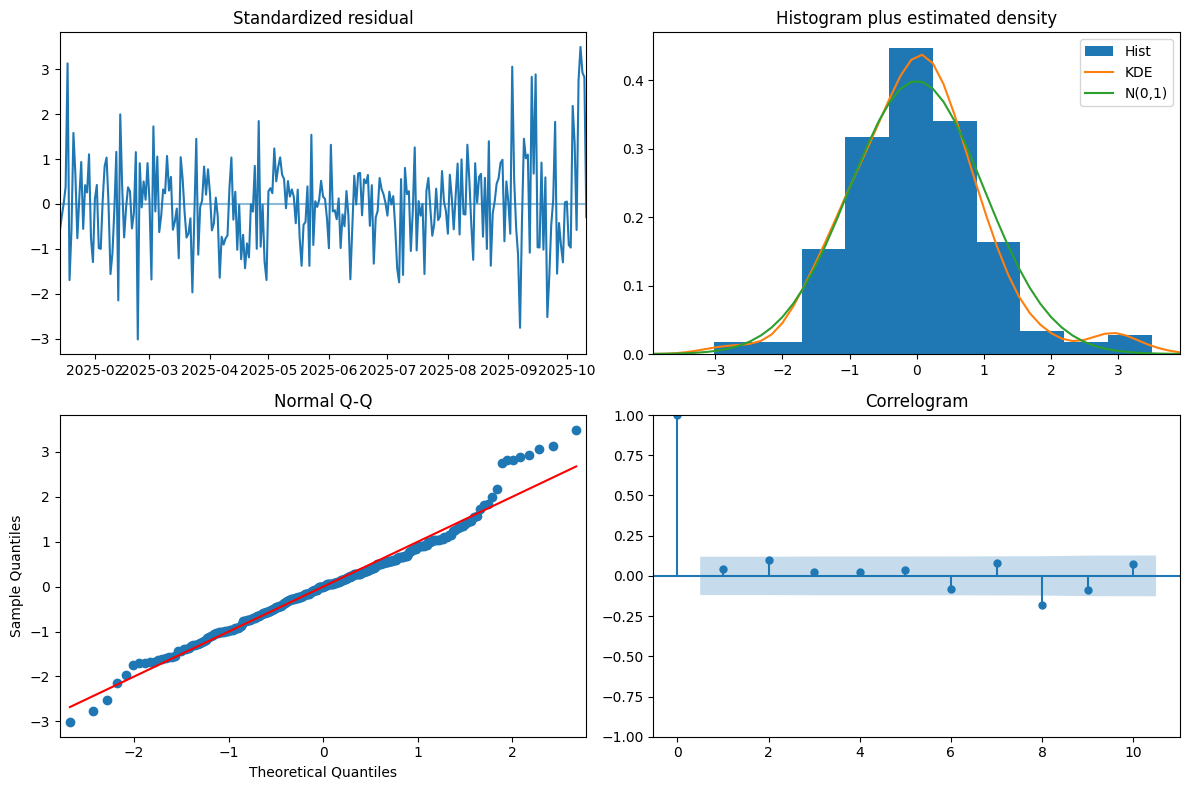

In [95]:
# Diagnostics for auto_arima model
auto_model.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [96]:
# Null Hypothesis (H₀): The residuals are independently distributed (no autocorrelation up to lag k)
# Alternative Hypothesis (H₁): The residuals show autocorrelation (model missed some pattern)
# p > 0.05	Fail to reject H₀	✅ Good — residuals look like white noise
# p <= 0.05	Reject H₀	❌ Bad — residuals show autocorrelation

from statsmodels.stats.diagnostic import acorr_ljungbox

# Check residuals
resids = auto_model.resid()
lb_test = acorr_ljungbox(resids, lags=[10], return_df=True)

print(lb_test)

      lb_stat  lb_pvalue
10  11.885831    0.29277


In [102]:
# Brute force vs auto_arima
# Brute-force ARIMA parameter search vs auto_arima
from scipy.optimize import brute
import warnings

warnings.filterwarnings("ignore")


def arima_objective(order, endog):
    """Fits ARIMA and returns AIC (lower is better)."""
    p, d, q = int(order[0]), int(order[1]), int(order[2])
    try:
        model = ARIMA(endog, order=(p, d, q))
        model_fit = model.fit()
        return model_fit.aic
    except Exception:
        return 1e10


# Run brute-force search on training data
# Ranges: p=0-4, d=0-2, q=0-4
ranges = (slice(0, 5, 1), slice(0, 3, 1), slice(0, 5, 1))

print("Running brute-force grid search (this may take a minute)...")
result = brute(
    func=arima_objective,
    ranges=ranges,
    args=(train["Usage"],),
    finish=None,
    full_output=True,
)

best_params = result[0]
min_aic = result[1]
brute_order = (int(best_params[0]), int(best_params[1]), int(best_params[2]))

print(f"\n=== Comparison ===")
print(f"Brute-force best order: {brute_order}, AIC: {min_aic:.2f}")
print(f"Auto-ARIMA best order:  {auto_model.order}, AIC: {auto_model.aic():.2f}")

# Test brute-force model on test set
brute_model = ARIMA(train["Usage"], order=brute_order)
brute_fitted = brute_model.fit()
brute_pred = brute_fitted.forecast(steps=len(test))
brute_mae = np.mean(np.abs(test["Usage"] - brute_pred))

print(f"\nTest set MAE comparison:")
print(f"Brute-force MAE: {brute_mae:.2f}")
print(f"Auto-ARIMA MAE:  {auto_mae:.2f}")
print(f"Naive MAE:       {naive_mae:.2f}")

Running brute-force grid search (this may take a minute)...

=== Comparison ===
Brute-force best order: (3, 2, 4), AIC: 2526.46
Auto-ARIMA best order:  (2, 1, 3), AIC: 2532.94

Test set MAE comparison:
Brute-force MAE: 151.60
Auto-ARIMA MAE:  740.59
Naive MAE:       289.54


In [98]:
# At that point we've got results for pre-shutdown and we need to do cross validation on test data
def cv_arima(data, order, n_splits=5):
    """Run expanding window CV for a given ARIMA order."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(data)):
        train_cv = data.iloc[train_idx]
        test_cv = data.iloc[test_idx]

        try:
            model = ARIMA(train_cv, order=order)
            fitted = model.fit()
            preds = fitted.forecast(steps=len(test_cv))
            mae = np.mean(np.abs(test_cv.values - preds.values))
            scores.append(mae)
            print(
                f"  Fold {fold+1}: Train={len(train_cv)}, Test={len(test_cv)}, MAE={mae:.2f}"
            )
        except Exception as e:
            print(f"  Fold {fold+1}: Failed - {e}")
            scores.append(np.nan)

    return scores

In [105]:
# Run on TRAIN set (df_pre_shutdown up to split point)
# We manually cinfiremed best order (2, 2, 3)
best_order = (2, 2, 3)
scores = cv_arima(train["Usage"], order=(2, 2, 3))  # auto_model.order)
mean_mae = np.mean(scores)
std_mae = np.std(scores)
print(f"\nCV Mean MAE: {mean_mae:.2f} ± {std_mae:.2f}")

  Fold 1: Train=47, Test=45, MAE=74.78
  Fold 2: Train=92, Test=45, MAE=97.17
  Fold 3: Train=137, Test=45, MAE=48.53
  Fold 4: Train=182, Test=45, MAE=61.74
  Fold 5: Train=227, Test=45, MAE=196.36

CV Mean MAE: 95.72 ± 52.82


In [114]:
# Now we found best order we need to train on all data?
df_smoothed["is_shutdown"] = 0
df_smoothed.loc[
    (df_smoothed.index > "2025-12-10") & (df_smoothed.index < "2026-01-05"),
    "is_shutdown",
] = 1

# 2. Train ARIMA(2,2,3) with exogenous on ALL data
model_final = ARIMA(
    df_smoothed["Usage"], order=best_order  # , exog=df_smoothed[["is_shutdown"]]
)
fitted_final = model_final.fit()
print(f"\nModel AIC: {fitted_final.aic:.2f}")
print(fitted_final.summary())


Model AIC: 3347.78
                               SARIMAX Results                                
Dep. Variable:                  Usage   No. Observations:                  340
Model:                 ARIMA(2, 2, 3)   Log Likelihood               -1667.889
Date:                Tue, 20 Jan 2026   AIC                           3347.779
Time:                        21:51:49   BIC                           3370.717
Sample:                    01-13-2025   HQIC                          3356.920
                         - 12-18-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5619      0.151     -3.732      0.000      -0.857      -0.267
ar.L2          0.2419      0.048      5.021      0.000       0.148       0.336
ma.L1          0.2793      0.181

In [115]:
print(f"Best order from auto_arima: {model_final.order}")

# Get forecast with confidence intervals (statsmodels)

forecast_days = 90  # 3 months
forecast_result = fitted_final.get_forecast(steps=forecast_days)
forecast_vals = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)

print(f"Forecast mean: {forecast_vals.mean():.0f}")
print(f"95% CI: [{conf_int.iloc[:, 0].mean():.0f}, {conf_int.iloc[:, 1].mean():.0f}]")

Best order from auto_arima: (2, 2, 3)
Forecast mean: 2483
95% CI: [1611, 3354]


In [116]:
# Plot the forecast
#
import plotly.graph_objects as go

last_date = df_smoothed.index.max()
forecast_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1), periods=forecast_days, freq="D"
)


fig = go.Figure()

# Historical data
fig.add_trace(
    go.Scatter(
        x=df_smoothed.index,
        y=df_smoothed["Usage"],
        mode="lines",
        name="Historical",
        line=dict(color="blue"),
    )
)

# Forecast
fig.add_trace(
    go.Scatter(
        x=forecast_dates,
        y=forecast_vals,
        mode="lines",
        name="3-Month Forecast",
        line=dict(color="red", width=2),
    )
)

# Confidence interval - USE .iloc[:, 0] and .iloc[:, 1]
fig.add_trace(
    go.Scatter(
        x=list(forecast_dates) + list(forecast_dates[::-1]),
        y=list(conf_int.iloc[:, 1]) + list(conf_int.iloc[:, 0][::-1]),  # ← Fixed!
        fill="toself",
        fillcolor="rgba(255,0,0,0.2)",
        line=dict(color="rgba(255,255,255,0)"),
        name="95% CI",
    )
)

fig.update_layout(
    title="ARIMA(2,2,3): 3-Month Forecast",
    xaxis_title="Date",
    yaxis_title="Usage",
    height=600,
)

fig.show()

In [117]:
# Auto-Arima way
# Future forecast: Train on pre-shutdown data, display full actuals + 3-month forecast
# Load full data (includes shutdown period Dec 19 - Jan 7)
df_full = pd.read_csv(
    "../data/gpu_in_use.csv", parse_dates=["DTime"], index_col="DTime"
)
df_full_daily = df_full.resample("D").mean()
df_full_smoothed = df_full_daily.ewm(span=10, adjust=False).mean()

# Train model on pre-shutdown data (df - ends Dec 19)
# df_smoothed already exists from earlier cells
model_future = auto_arima(
    df_smoothed["Usage"],
    seasonal=False,
    stepwise=False,  # This is a critical paramter - slow but optimal if False
    suppress_warnings=True,
)
print(f"Model order: {model_future.order}")

# Forecast 90 days (3 months) from Jan 13, 2026
forecast_days = 90
future_forecast, future_conf_int = model_future.predict(
    n_periods=forecast_days, return_conf_int=True, alpha=0.05
)

# Create future date index
last_date = df_full_smoothed.index.max()
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1), periods=forecast_days, freq="D"
)

# Plot
fig = go.Figure()

# Full historical data (includes shutdown)
fig.add_trace(
    go.Scatter(
        x=df_full_smoothed.index,
        y=df_full_smoothed["Usage"],
        mode="lines",
        name="Actual (smoothed)",
        line=dict(color="blue"),
    )
)

# Future forecast
fig.add_trace(
    go.Scatter(
        x=future_dates,
        y=future_forecast,
        mode="lines",
        name="Forecast",
        line=dict(color="red"),
    )
)

# Confidence interval
fig.add_trace(
    go.Scatter(
        x=list(future_dates) + list(future_dates[::-1]),
        y=list(future_conf_int[:, 1]) + list(future_conf_int[:, 0][::-1]),
        fill="toself",
        fillcolor="rgba(255,0,0,0.2)",
        line=dict(color="rgba(255,255,255,0)"),
        name="95% CI",
    )
)

# Mark shutdown period
fig.add_vrect(
    x0="2025-12-19",
    x1="2026-01-07",
    fillcolor="gray",
    opacity=0.2,
    annotation_text="Shutdown",
    annotation_position="top left",
)

fig.update_layout(
    title="GPU Usage: Historical Data + 3-Month Forecast (Jan-Apr 2026)",
    xaxis_title="Date",
    yaxis_title="Usage",
)
fig.show()

Model order: (2, 1, 3)
